In [1]:
import pandas as pd
df = pd.read_csv('ML_Data_Insight_121016.csv', header=1)
df.head()
Y=df.ix[0:,'y']
X1=df.ix[0:,'x1']
X2=df.ix[0:,'x1']
X3=df.ix[0:,'x1']




In [2]:
import scipy.stats as stats


stats.f_oneway(df.ix[1:,'y'],df.ix[1:, 'x3'])
#stats.f_oneway(df.ix[1:,'y'],df.ix[1:, 'x2'])
#stats.f_oneway(df.ix[1:,'y'],df.ix[1:, 'x3'])


F_onewayResult(statistic=1328.2544584402767, pvalue=2.8752562884347074e-224)

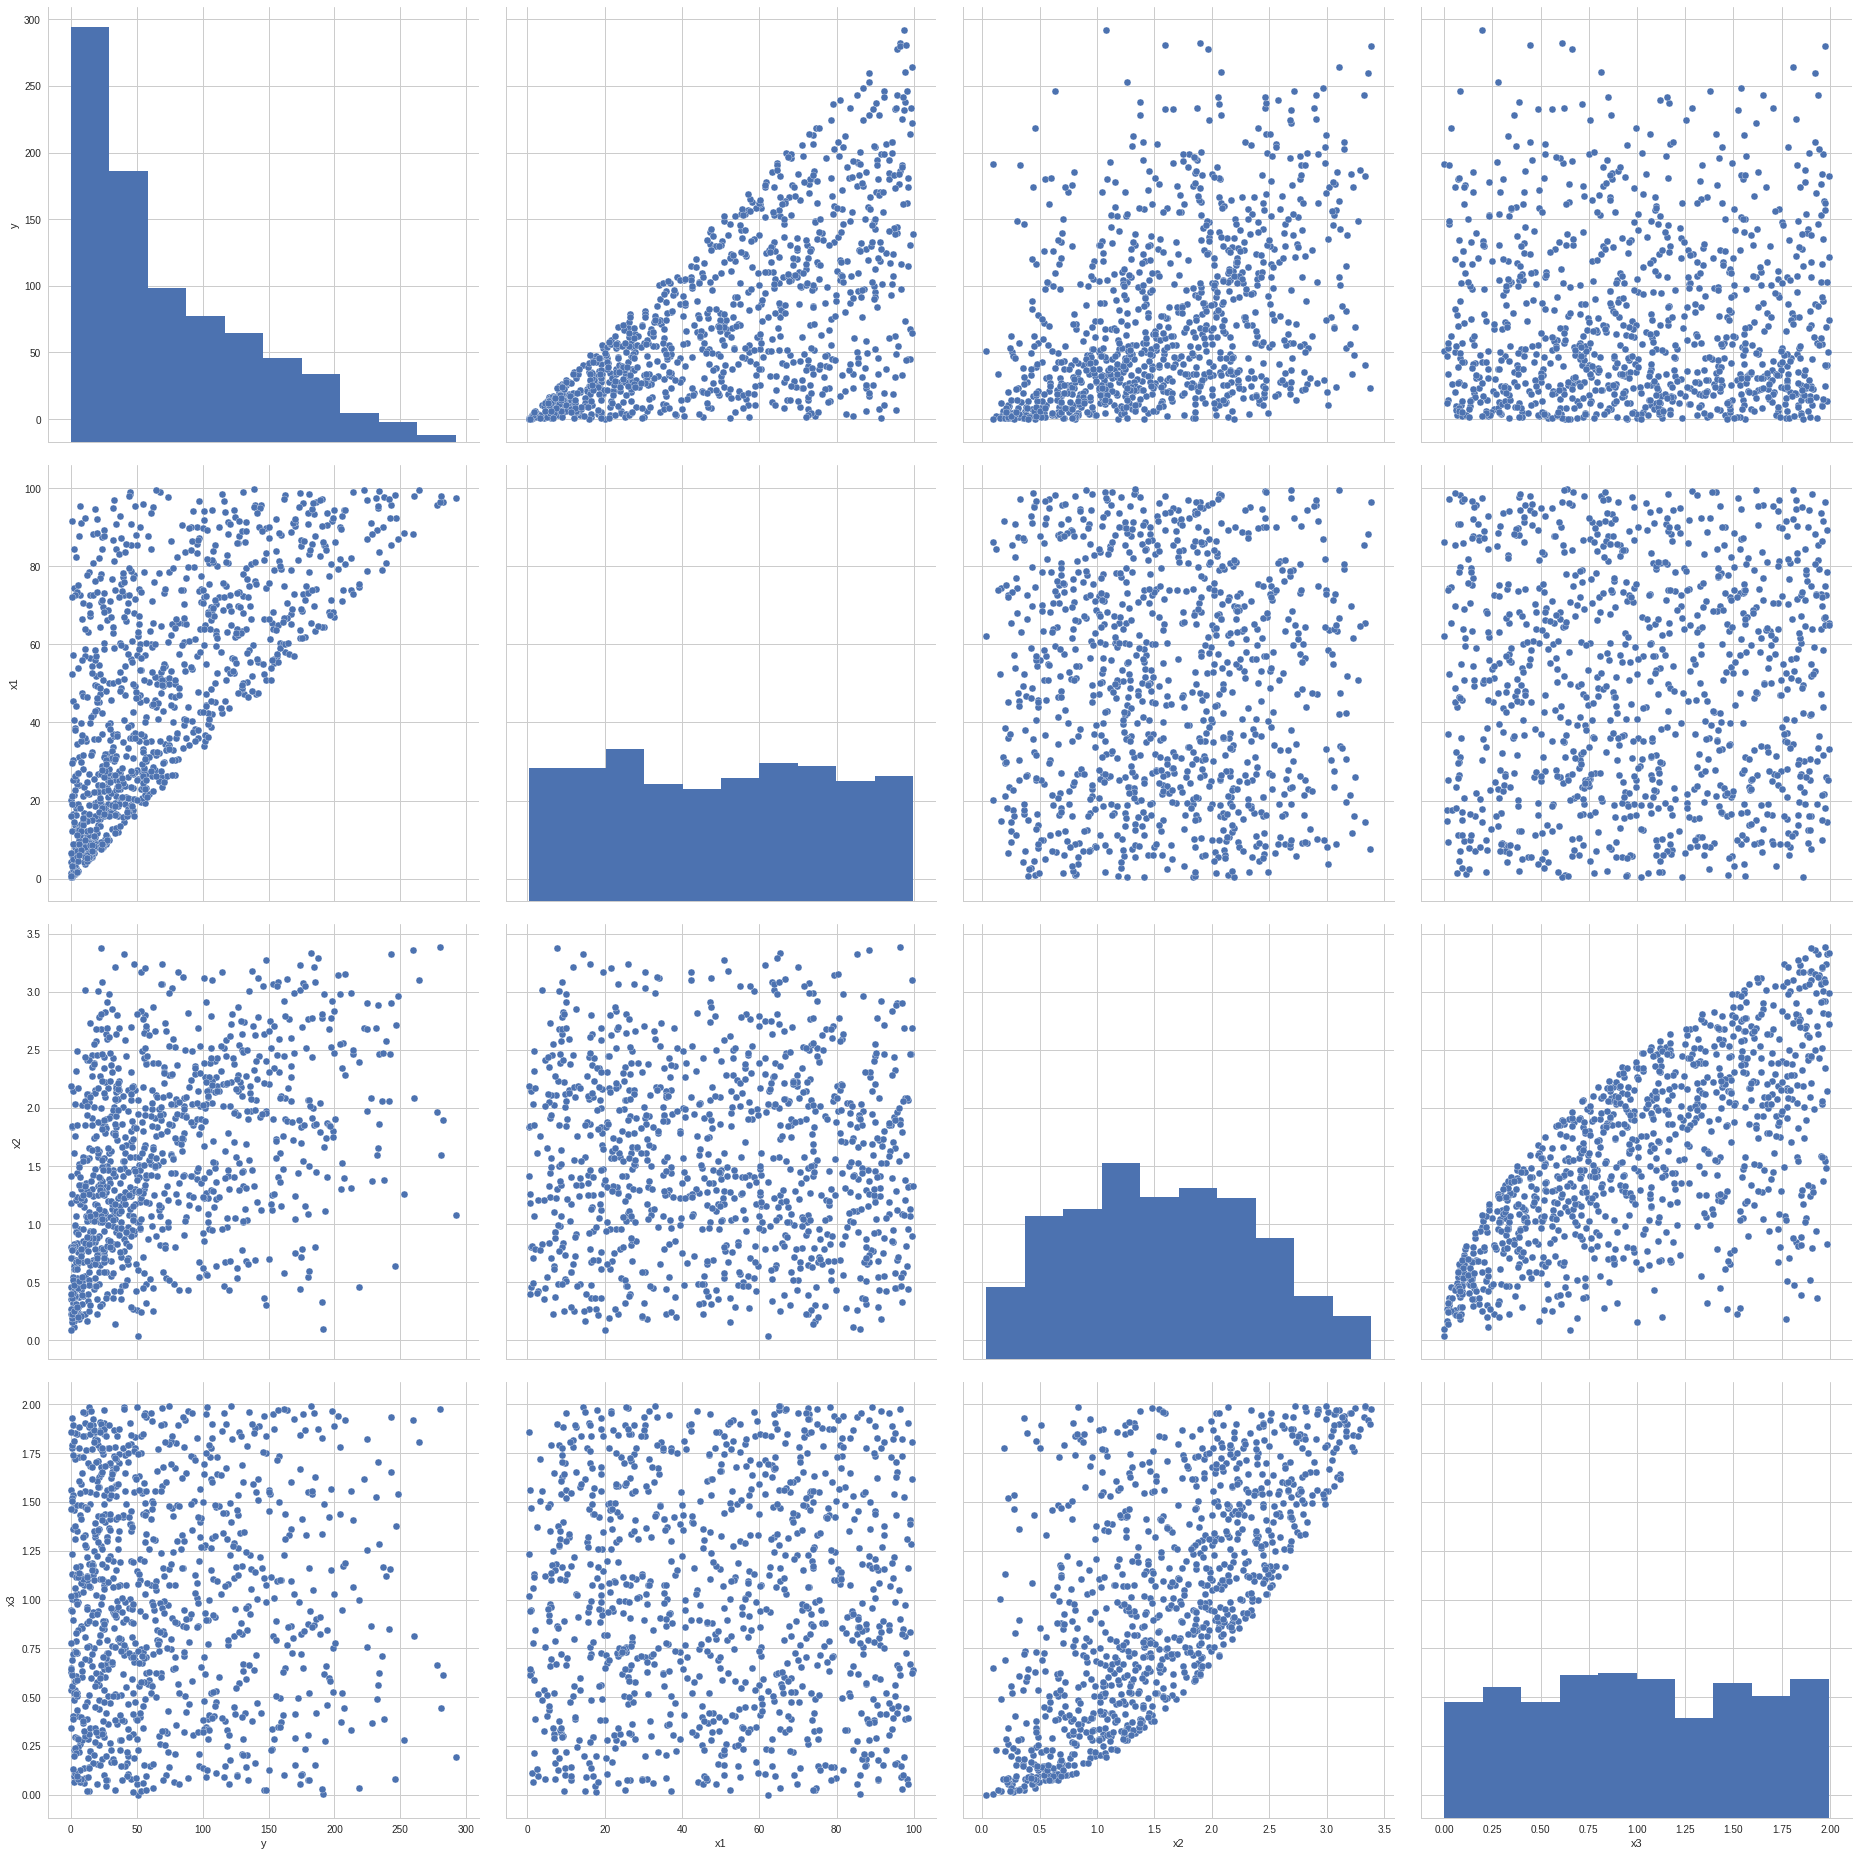

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')
cols = ['y','x1', 'x2', 'x3']
sns.pairplot(df[cols], size=6.5)
plt.show()


In [4]:
print ( df.cov() )
print ( df.corr() )


              y           x1         x2        x3
y   4133.446622  1232.772400  21.546143  0.440736
x1  1232.772400   826.455605  -0.446825  0.139798
x2    21.546143    -0.446825   0.616575  0.305066
x3     0.440736     0.139798   0.305066  0.327083
           y        x1        x2        x3
y   1.000000  0.666986  0.426796  0.011987
x1  0.666986  1.000000 -0.019794  0.008503
x2  0.426796 -0.019794  1.000000  0.679316
x3  0.011987  0.008503  0.679316  1.000000


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


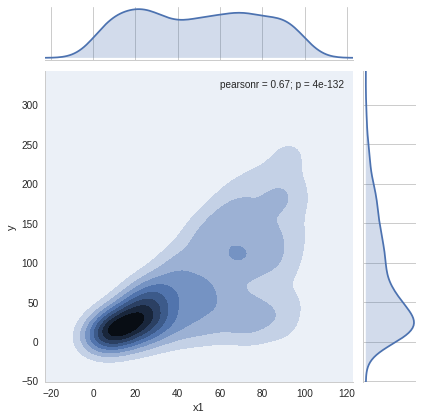

In [5]:
sns.jointplot(x="x1", y="y", data=df, kind="kde", marker = '+')
plt.show()



/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


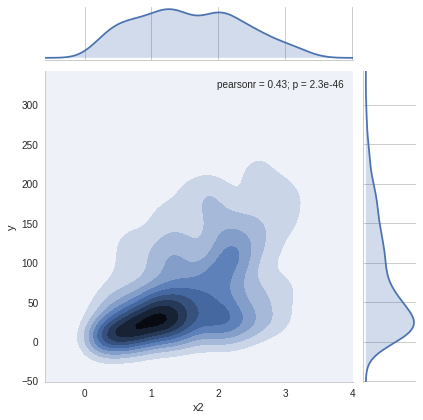

In [6]:
sns.jointplot(x="x2", y="y", data=df, kind="kde")
#sns.plot_joint(plt.scatter, c="w", s=30, linewidth=1, marker="+")
#g.ax_joint.collections[0].set_alpha(0)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


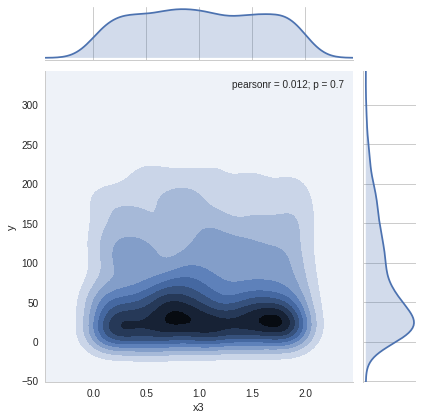

In [7]:
sns.jointplot(x="x3", y="y", data=df, kind="kde")
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


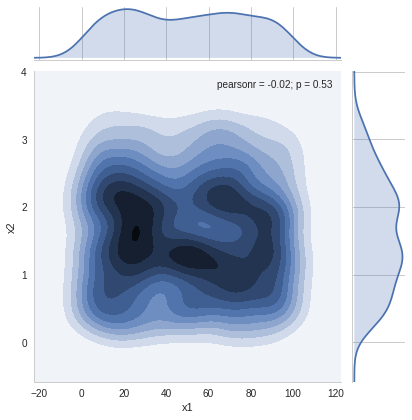

In [8]:
sns.jointplot(x="x1", y="x2", data=df, kind="kde")
plt.show()


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


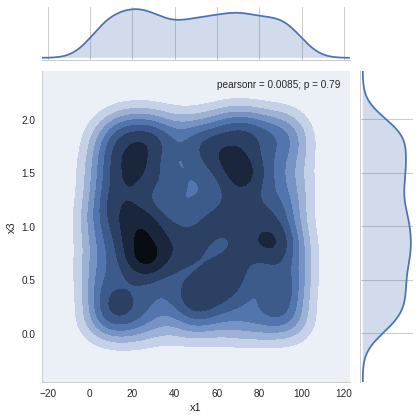

In [9]:
sns.jointplot(x="x1", y="x3", data=df, kind="kde")
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


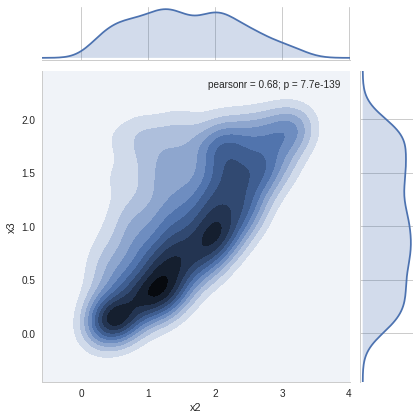

In [10]:
sns.jointplot(x="x2", y="x3", data=df, kind="kde")
plt.show()

In [11]:
from mpl_toolkits.mplot3d import Axes3D

In [12]:
#fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# Axes3D.contour(X, Y, Z, *args, **kwargs)¶

In [13]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from collections import Counter




In [53]:
# Prøver lineær regresjon selv om vi ser at sammenhengen er noe mere kompliser for enkelte av variablene. 
# Vi har kun 3 features og ett relativt lite datasett. Det vil si at det kun er 8 mulige
# kombinasjoner av input features: x1, x2, x3, x1x2,x1x3, x2x3 og x1x2x3. (I prinsippet 9
# hvis vi antar att y er uavhengig av all input variable, men vi ser av datasettet at dette ikke er  tilfelle )
# Vi bare prøver oss frem med all mulig kombinasjoner og ser hva som gir best resultat
# Antar att datsettet er u-ordnet. De 800 første rekkene brukes til generering av modell, og de resterenede
# til validering

lm = LinearRegression(normalize=True)

y_train=df.ix[0:800, (0)]
x1x2x3_train=df.ix[0:800, (1,2,3)]
x1x2_train=df.ix[0:800, (1,2)]
x1x3_train=df.ix[0:800, (1,3)]
x2x3_train=df.ix[0:800, (2,3)]
x1_train=df.ix[0:800, (1)]
x2_train=df.ix[0:800, (2)]
x3_train=df.ix[0:800, (3)]

y_val=df.ix[801:, (0)]
x1x2x3_val=df.ix[801:, (1,2,3)]
x1x2_val=df.ix[801:, (1,2)]
x1x3_val=df.ix[801:, (1,3)]
x2x3_val=df.ix[801:, (2,3)]
x1_val=df.ix[801:, (1)]
x2_val=df.ix[801:, (2)]
x3_val=df.ix[801:, (3)]

In [54]:

lm.fit(x1x2x3_train,y_train)
print ( lm.score(x1x2x3_train, y_train) )

0.805415155915


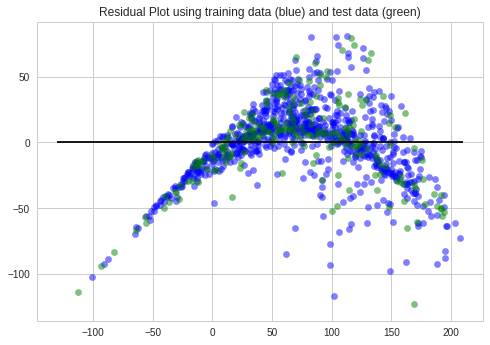

In [55]:
#Vi ser av det forehåned at vi får best resultat når vi bruker alle featurene x1, x2, x3, så vi bruker denne modellen

plt.scatter(lm.predict(x1x2x3_train), lm.predict(x1x2x3_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1x2x3_val), lm.predict(x1x2x3_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=-130, xmax=210)
plt.title('Residual Plot using training data (blue) and test data (green)')

plt.show()

# Ser av rest plottet at modellen ikke er spesielt god. For en god modell så burde residuen 
# verdien værr normal fordelt med mean = 0. AV formen på residuene så er det nærliggende
# å forsøke en polynom tilpasning, et 2-grads polynom ser ut til å skulle holde.

0.637198017109


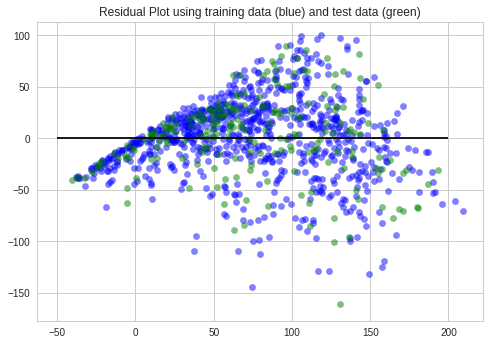

In [51]:
lm.fit(x1x2_train,y_train)
print ( lm.score(x1x2_train, y_train) )
#Vi gjør det bare litt dårliger når vi dropper x3, grunne er at x3 er sterk korrelert med x2
plt.scatter(lm.predict(x1x2_train), lm.predict(x1x2_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1x2_val), lm.predict(x1x2_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=-50, xmax=200)
plt.title('Residual Plot using training data (blue) and test data (green)')

plt.show()

0.454026094636


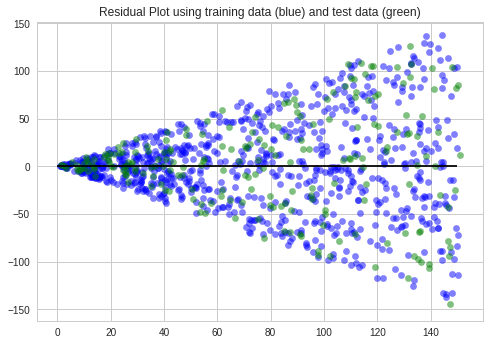

In [50]:
lm.fit(x1x3_train,y_train)
print ( lm.score(x1x3_train, y_train) )
plt.scatter(lm.predict(x1x3_train), lm.predict(x1x3_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1x3_val), lm.predict(x1x3_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=0, xmax=150)
plt.title('Residual Plot using training data (blue) and test data (green)')

plt.show()

0.309558986877


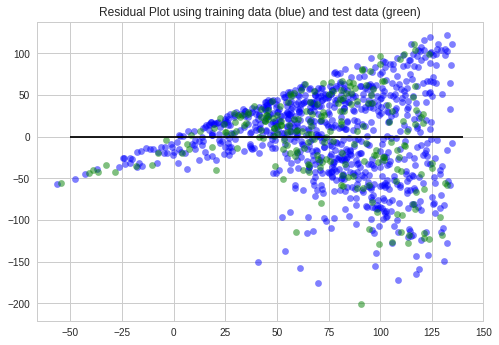

In [49]:
lm.fit(x2x3_train,y_train)
print ( lm.score(x2x3_train, y_train) )
plt.scatter(lm.predict(x2x3_train), lm.predict(x2x3_train) - y_train, c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x2x3_val), lm.predict(x2x3_val) - y_val, c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=-50, xmax=140)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

0.454024668386


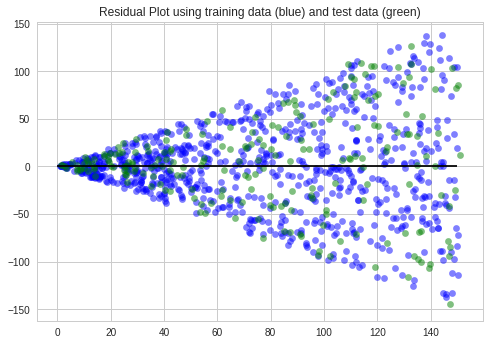

In [47]:
lm.fit(x1_train.values.reshape(-1,1),y_train.values.reshape(-1,1)  )
print ( lm.score(x1_train.values.reshape(-1,1), y_train.values.reshape(-1,1)     ))

plt.scatter(lm.predict(x1_train.values.reshape(-1,1)), lm.predict(x1_train.values.reshape(-1,1)) - y_train.values.reshape(-1,1), c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x1_val.values.reshape(-1,1) ), lm.predict(x1_val.values.reshape(-1,1) ) - y_val.values.reshape(-1,1), c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=0, xmax=150)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

#todo plot med y logaritmisk !!

0.170057646016


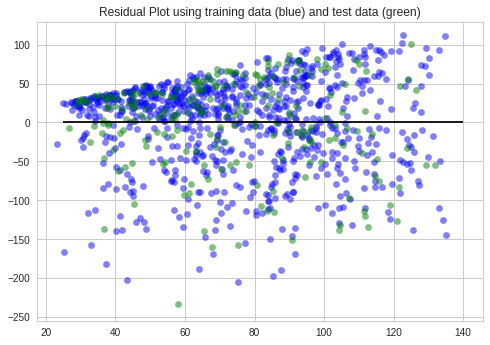

In [44]:
lm.fit(x2_train.values.reshape(-1,1), y_train.values.reshape(-1,1) )
print ( lm.score(x2_train.values.reshape(-1,1),  y_train.values.reshape(-1,1) ) )

plt.scatter(lm.predict(x2_train.values.reshape(-1,1)), lm.predict(x2_train.values.reshape(-1,1)) - y_train.values.reshape(-1,1), c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x2_val.values.reshape(-1,1) ), lm.predict(x2_val.values.reshape(-1,1) ) - y_val.values.reshape(-1,1), c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=25, xmax=140)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()

0.000192378969286


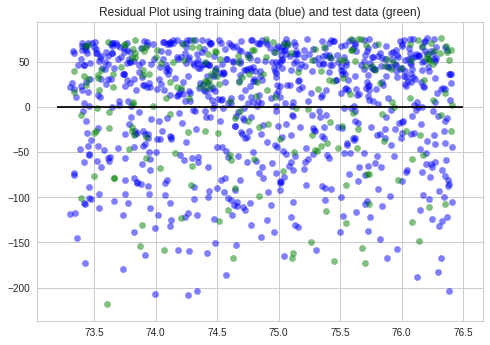

In [46]:
lm.fit(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1) )
print ( lm.score(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1)  ))

plt.scatter(lm.predict(x3_train.values.reshape(-1,1)), lm.predict(x3_train.values.reshape(-1,1)) - y_train.values.reshape(-1,1), c='b', s=40, alpha=0.5)
plt.scatter(lm.predict(x3_val.values.reshape(-1,1) ), lm.predict(x3_val.values.reshape(-1,1) ) - y_val.values.reshape(-1,1), c='g', s=40, alpha=0.5)
plt.hlines(y=0, xmin=73.2, xmax=76.5)
plt.title('Residual Plot using training data (blue) and test data (green)')
plt.show()